# Transport Trends Analysis: Exploring Long Term Vehicle Registration and Mobility Patterns.

## A Data-Driven Exploration of Transport Activity Over Time

# Project overview

Transportation systems are a key indicator of economic activity, mobility trends as well as infrastructure demand. Understanding how vehicle registrations and licensing patterns evolve over time can support governments and businesses in making informed decisions.

This analysis explores historical transport data to identify long-term trends, dominant vehicle categories and shifts in transport demand.

## Objectives

This analysis aims to:

- Understand long-term transport registration and licensing trends
- Identify dominant vehicle categories in the transport system
- Explore changes in transport demand over time
- Assess data quality and structure for analytical readiness
- Generate insights to support transport planning and decision-making

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Defining the file name we are looking for
file_name = "transport-january-2026-csv.csv"

#Check if the file is right here in the main folder, otherwise check the Kaggle input folder
if os.path.exists(file_name):
    path_to_open = file_name
else:
    # If it's inside a Kaggle input subfolder, let's find it cleanly
    path_to_open = None
    for root, dirs, files in os.walk("/kaggle/input"):
        if file_name in files:
            path_to_open = os.path.join(root, file_name)
            break

if path_to_open is None:
    print(" Could not find the file. Please check the 'Input' section on your right sidebar!")
else:
    print(f" Found file at: {path_to_open}")




 Found file at: /kaggle/input/datasets/lalit7881/transport-vehicle-registrations-january-2026/transport-january-2026-csv.csv


### Technical Note: Resolving Environment File Paths
During the initial pipeline setup, a common infrastructure roadblock occurred: `FileNotFoundError` followed by `IsADirectoryError`. 

* **The Cause:** Kaggle sandboxes store dataset uploads inside dynamically named subdirectories within `/kaggle/input/`, rather than the project root folder. Attempting to loop broadly through directories caused Python to treat a folder path as a file.
* **The Solution:** A robust, automated script was implemented using `os.walk()` to dynamically crawl subdirectories, locate the exact file name string safely, and isolate its absolute path before calling `pd.read_csv()`. This ensures the code runs flawlessly across different user environments without hardcoded paths crashing the program.

Before conducting any analysis, it is important to understand the structure and contents of the dataset. This includes identifying the available variables, their data types and assessing overall data quality.

Understanding the data helps ensure that the analysis is based on accurate and reliable information.

In [56]:
# We are loading the CSV file exactly as it is, without changing anything yet.
df = pd.read_csv("/kaggle/input/datasets/lalit7881/transport-vehicle-registrations-january-2026/transport-january-2026-csv.csv")

df.head()

,Series_reference,Period,Data_value,Suppressed,STATUS,UNITS,Magnitude,Subject,Group,Series_title_1,Series_title_2,Series_title_3,Series_title_4,Series_title_5
0,TPTA.S22IA,1970.12,2771.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons up to 850 cc,NaN,NaN,NaN,NaN
1,TPTA.S22IA,1971.12,2076.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons up to 850 cc,NaN,NaN,NaN,NaN
2,TPTA.S22IA,1972.12,2037.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons up to 850 cc,NaN,NaN,NaN,NaN
3,TPTA.S22IA,1973.12,2101.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons up to 850 cc,NaN,NaN,NaN,NaN
4,TPTA.S22IA,1974.12,1282.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons up to 850 cc,NaN,NaN,NaN,NaN


In [57]:
df.shape

(45542, 14)

In [58]:
df.columns

Index(['Series_reference', 'Period', 'Data_value', 'Suppressed', 'STATUS',
       'UNITS', 'Magnitude', 'Subject', 'Group', 'Series_title_1',
       'Series_title_2', 'Series_title_3', 'Series_title_4', 'Series_title_5'],
      dtype='object')

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45542 entries, 0 to 45541
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Series_reference  45542 non-null  object 
 1   Period            45542 non-null  float64
 2   Data_value        45501 non-null  float64
 3   Suppressed        0 non-null      float64
 4   STATUS            45542 non-null  object 
 5   UNITS             45542 non-null  object 
 6   Magnitude         45542 non-null  int64  
 7   Subject           45542 non-null  object 
 8   Group             45542 non-null  object 
 9   Series_title_1    45542 non-null  object 
 10  Series_title_2    22458 non-null  object 
 11  Series_title_3    0 non-null      float64
 12  Series_title_4    0 non-null      float64
 13  Series_title_5    0 non-null      float64
dtypes: float64(6), int64(1), object(7)
memory usage: 4.9+ MB


**Summary statistics**

Descriptive statistics provide an overview of the numerical variables in the dataset, including measures (count, mean, standard deviation, minimum and maximum values.)

These statistics help identify potential outliers and the overall distribution of the data.

In [60]:
df.describe()

,Period,Data_value,Suppressed,Magnitude,Series_title_3,Series_title_4,Series_title_5
count,45542.000000,4.550100e+04,0.0,45542.0,0.0,0.0,0.0
mean,2003.483932,1.857272e+05,NaN,0.0,NaN,NaN,NaN
std,13.743173,5.959473e+05,NaN,0.0,NaN,NaN,NaN
min,1961.010000,0.000000e+00,NaN,0.0,NaN,NaN,NaN
25%,1994.010000,2.770000e+02,NaN,0.0,NaN,NaN,NaN
50%,2004.100000,4.492000e+03,NaN,0.0,NaN,NaN,NaN
75%,2015.060000,2.340300e+04,NaN,0.0,NaN,NaN,NaN
max,2026.010000,4.678980e+06,NaN,0.0,NaN,NaN,NaN


In [61]:
df.sample(20)

,Series_reference,Period,Data_value,Suppressed,STATUS,UNITS,Magnitude,Subject,Group,Series_title_1,Series_title_2,Series_title_3,Series_title_4,Series_title_5
40307,TPTQ.S56AA,2022.12,2359745.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Cars,12 Months,NaN,NaN,NaN
5139,TPTM.S22IG,1978.07,62.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons 5001 cc & Over,NaN,NaN,NaN,NaN
28748,TPTM.S56IA,2022.09,35677.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Motor Cycles,12 Months,NaN,NaN,NaN
32981,TPTM.S56NB,2011.11,510.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Exempt Vehicles,6 Months,NaN,NaN,NaN
19469,TPTQ.S22IK,2017.09,484.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Power Cycles,NaN,NaN,NaN,NaN
33398,TPTM.S56NZ,2008.07,11712.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Exempt Vehicles,Total both periods,NaN,NaN,NaN
14436,TPTM.S22NI,2015.10,40.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,Commercial Vehicles 10501 to 14500 Kg,NaN,NaN,NaN,NaN
29998,TPTM.S56JA,2012.08,9293.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Mopeds,12 Months,NaN,NaN,NaN
43011,TPTQ.S56NA,2014.12,13458.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Exempt Vehicles,12 Months,NaN,NaN,NaN
8281,TPTM.S22JZ,2023.07,6495.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars/Stat'n Wags Prev Reg'd Ovrseas,NaN,NaN,NaN,NaN


## Initial Observations

This dataset contains historical transport statistics covering vehicle registrations, licensing activity and fleet composition across multiple decades (1970 onward). It provides 45542 observations across 14 variables.

The dataset captures:
- The **Period** variable suggests a time-series structure spanning multiple decades.
- The **Data_value** column represents the primary quantitative measure used for analysis.
- The dataset includes multiple classification levels through **Group**, **Series_title_1**, and **Series_title_2**, allowing for detailed segmentation of transport activity.
- Several columns (**Series_title_3–5**) contain no data and are likely redundant.
- The dataset includes both vehicle registration and vehicle licensing information, providing a dual perspective on transport activity.

Overall, the dataset is well-suited for time-series trend analysis, category comparisons and transport sector insights.

# Data Quality Assessment

This section evaluates the dataset for missing values, duplicates and other structural issues before analysis.

In [62]:
#checking for missing values
df.isnull().sum()

Series_reference        0
Period                  0
Data_value             41
Suppressed          45542
STATUS                  0
UNITS                   0
Magnitude               0
Subject                 0
Group                   0
Series_title_1          0
Series_title_2      23084
Series_title_3      45542
Series_title_4      45542
Series_title_5      45542
dtype: int64

## Missing Values 

The missing value analysis revealed several data quality considerations:

- **Data_value** contains 41 missing observations.
- **Series_title_2** contains 23,084 missing values.
- **Suppressed** contains 45,542 missing values (100% missing).
- **Series_title_3**, **Series_title_4**, and **Series_title_5** contain 45,542 missing values each (100% missing).

The complete absence of data in the Suppressed and Series_title_3–5 columns suggests that these variables do not contribute meaningful information and may be removed during data cleaning.

The relatively small number of missing values in Data_value can likely be handled through row removal without significantly impacting the analysis.

In [63]:
df.duplicated().sum()

np.int64(0)

# Business Questions

To guide this exploratory analysis, the study is structured around three levels of analysis:

- **Univariate Analysis**: Understanding individual variables in isolation.
- **Bivariate Analysis**: Exploring relationships between two variables.
- **Multivariate Analysis**: Identifying patterns across multiple variables.

This ensures the analysis remains focused, structured, and aligned with real-world analytical thinking.

# Key Business Questions

## Univariate Analysis

1. What are the most dominant transport categories in the dataset?
2. What is the overall distribution of transport activity values (`Data_value`)?

## Bivariate Analysis

3. How has total transport activity changed over time?
4. Which transport categories contribute the most to total activity?

## Multivariate Analysis

5. How do transport categories evolve over time in terms of activity levels?

## Applied Business Question (Key Focus)
6. How can the observed transport trends be used to inform policy decisions, infrastructure planning and market opportunities?

In [71]:
# Drop columns that are completely empty (they just take up space)
empty_columns = ['Suppressed', 'Series_title_3', 'Series_title_4', 'Series_title_5']

df_clean = df_clean.drop(columns=empty_columns, errors='ignore')

# Drop rows where the actual data count (Data_value) is missing
df_clean = df_clean.dropna(subset=['Data_value'])

# The 'Period' column looks like a decimal (e.g., 2025.12). 
# Let's extract just the Year as a clean whole number.
df_clean['Year'] = df_clean['Period'].astype(str).str.split('.').str[0].astype(int)

# Let's look at the two main groups of transport data we have
print("--- Data Successfully Cleaned! ---")
print(f"Total rows available for analysis: {df_clean.shape[0]}\n")

print("Top Transport Categories:")
print(df_clean['Group'].value_counts())


--- Data Successfully Cleaned! ---
Total rows available for analysis: 45501

Top Transport Categories:
Group
New and Ex-Oseas Motor Vehicles Registered by Type    23084
Motor Vehicles Currently Licensed by Type             22417
Name: count, dtype: int64


## Note on Data Cleaning Approach

During the data cleaning process, an issue was encountered where selected columns for removal were not present in the dataset at the time of execution. This occurred due to variations in column availability during iterative preprocessing.

To ensure a robust and error-free pipeline, the `errors='ignore'` parameter was used when dropping columns. This allows the analysis to continue even if some specified columns are missing.

This approach improves the flexibility and stability of the data preprocessing workflow, especially when working with evolving or partially structured datasets.

# Univariate Analysis

Univariate analysis focuses on exploring individual variables in isolation. This helps us understand the distribution, frequency and overall structure of key variables before examining relationships between them.

In this section, we analyze:
- Distribution of transport activity values
- Most common transport categories
- Distribution of observations over time

## 1. Distribution of Transport Activity (Data_value)

This plot shows how transport activity values are distributed across the dataset. It helps identify whether the data is evenly distributed or skewed towards certain ranges.

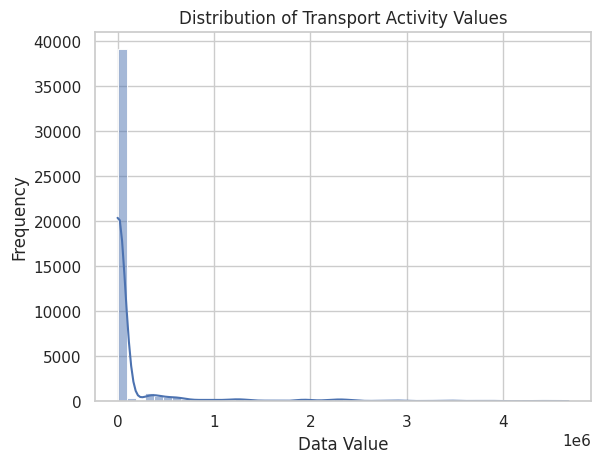

In [72]:
plt.figure()

sns.histplot(df_clean["Data_value"], bins=50, kde=True)

plt.title("Distribution of Transport Activity Values")
plt.xlabel("Data Value")
plt.ylabel("Frequency")

plt.show()

### Insight

The distribution of transport activity values is highly skewed, with a large concentration of lower values and a long tail of higher values.

This suggests that:
- A small number of transport categories or time periods account for very high activity levels
- Most transport observations are relatively low in magnitude
- The dataset likely contains a few dominant transport segments driving overall activity

## 2. Most Frequent Transport Categories

This analysis shows the most common transport categories in the dataset based on frequency of occurrence.

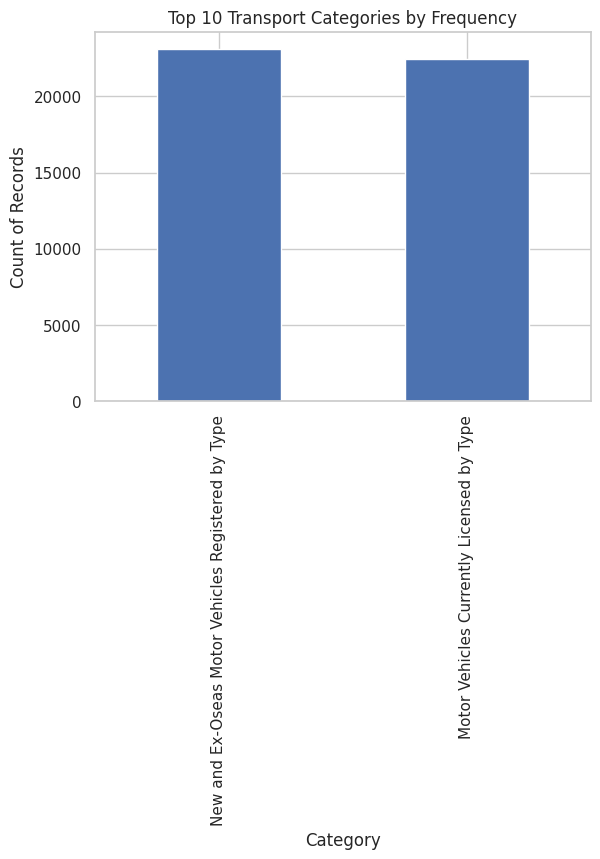

In [75]:
top_categories = df_clean["Group"].value_counts().head(10)

top_categories.plot(kind="bar")

plt.title("Major Transport Categories by Frequency")
plt.xlabel("Category")
plt.ylabel("Count of Records")

plt.show()

### Insight

The dataset is heavily dominated by two major transport reporting systems:

- New and Ex-Oseas Motor Vehicle Registrations  
- Motor Vehicles Currently Licensed by Type  

These two groups account for the vast majority of recorded observations.

This indicates that:
- The dataset is structured around two core transport monitoring systems rather than many equally distributed categories
- Frequency of records is driven by reporting structure not actual transport demand
- Further analysis should focus on these two groups separately, as they represent fundamentally different transport activities (new registrations vs existing fleet licensing)

## 3. Distribution of Observations Over Time

This plot shows how transport-related records are distributed across years, helping identify periods of higher or lower reporting activity.

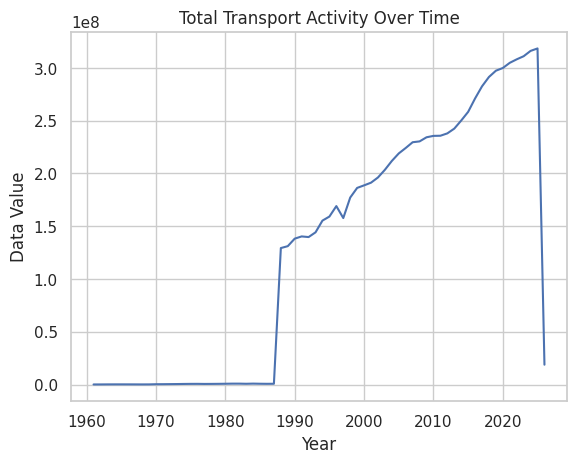

In [78]:
yearly_trend = df_clean.groupby("Year")["Data_value"].sum()

yearly_trend.plot()

plt.title("Total Transport Activity Over Time")
plt.xlabel("Year")
plt.ylabel("Data Value")

plt.show()

### Insight

The apparent decline in records after 2020 is not a decline in transport activity, but rather a change in data reporting frequency.

When analyzing actual transport volume (Data_value), a different pattern emerges, showing that transport activity is driven by long-term structural trends rather than recent reporting fluctuations.

This highlights the importance of distinguishing between:
- Data availability (number of records)
- Actual transport activity (Data_value)

# Bivariate Analysis

Bivariate analysis explores the relationship between two variables to identify patterns, trends and differences within the data.

In this section, we focus on:
- How transport activity changes over time
- Which transport categories contribute most to overall activity

## 1. Transport Activity Over Time

This analysis explores how total transport activity (`Data_value`) changes across different years.

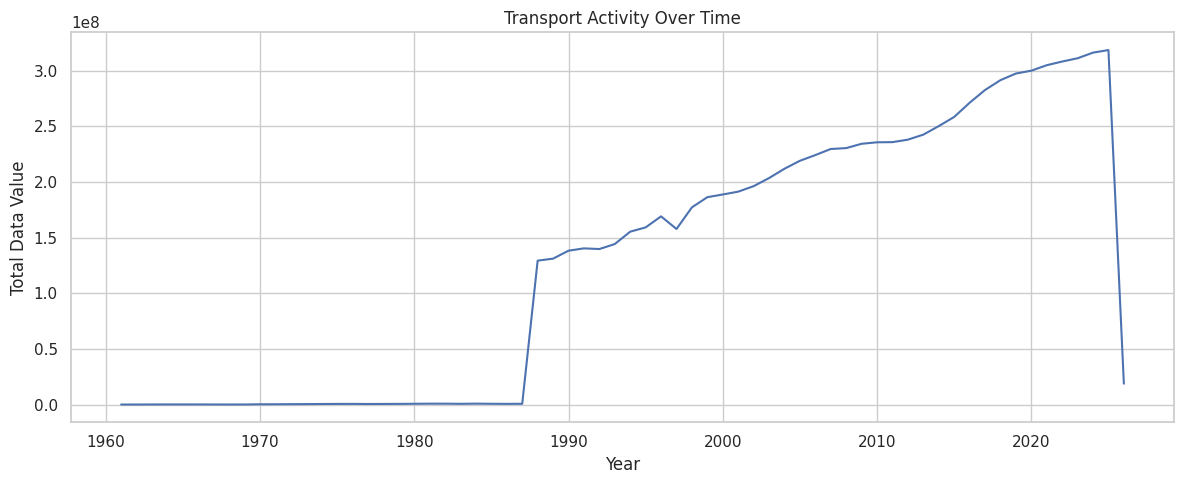

In [80]:
yearly_total = df_clean.groupby("Year")["Data_value"].sum()

plt.figure(figsize=(12,5))
plt.plot(yearly_total.index, yearly_total.values)

plt.title("Transport Activity Over Time")
plt.xlabel("Year")
plt.ylabel("Total Data Value")
plt.tight_layout()
plt.show()

### Insight

Transport activity varies across time, showing periods of growth and decline.

Overall, later years tend to show higher total activity compared to earlier years, indicating long-term expansion in transport-related activity.

However, fluctuations suggest that transport activity is influenced by changing conditions over time rather than following a perfectly linear trend.

## 2. Transport Activity by Category

This analysis compares total transport activity across different transport groups to identify which categories contribute the most.

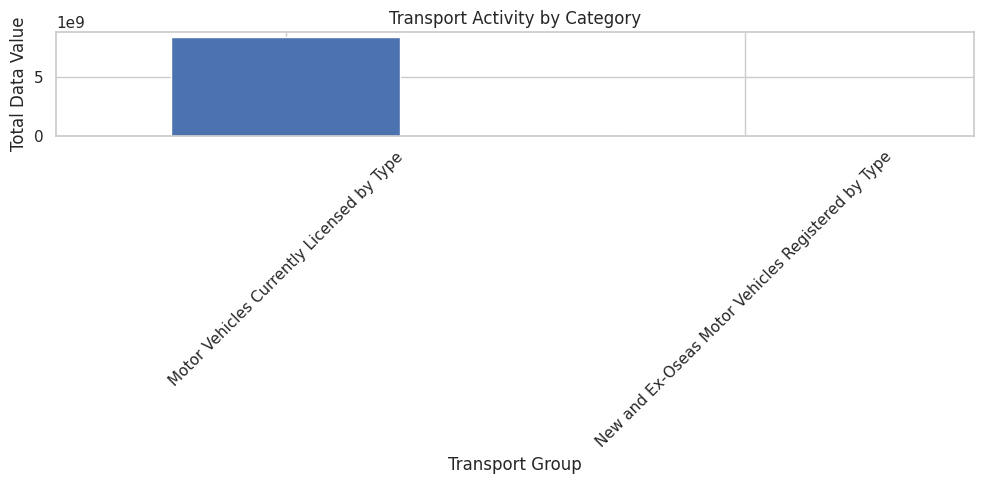

In [81]:
group_total = df_clean.groupby("Group")["Data_value"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
group_total.plot(kind="bar")

plt.title("Transport Activity by Category")
plt.xlabel("Transport Group")
plt.ylabel("Total Data Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Transport activity is unevenly distributed across categories.

A small number of transport groups account for the majority of total activity, while other categories contribute significantly less.

This indicates that transport systems are concentrated around key vehicle-related categories rather than being evenly distributed across all groups.

# Multivariate Analysis

Multivariate analysis explores relationships between three or more variables to understand how different dimensions interact over time.

In this section, we focus on how transport categories evolve over time in terms of activity levels.

## 1. Transport Category Evolution Over Time

This analysis explores how different transport categories change in activity levels across time.

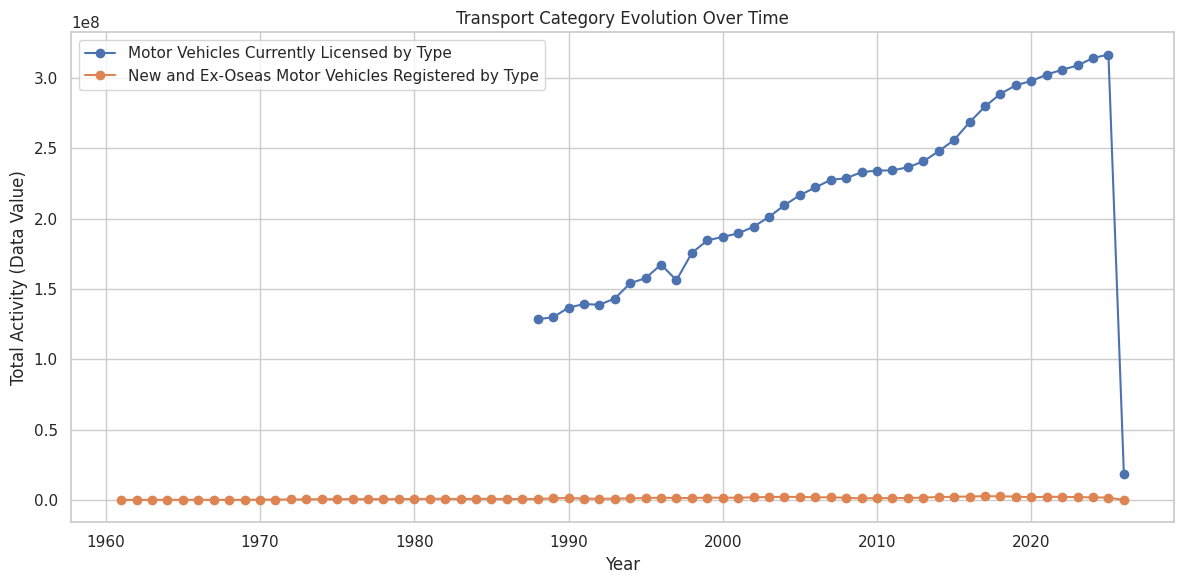

In [82]:
top_groups = df_clean.groupby("Group")["Data_value"].sum().sort_values(ascending=False).head(3).index

plt.figure(figsize=(12,6))

for group in top_groups:
    temp = df_clean[df_clean["Group"] == group]
    trend = temp.groupby("Year")["Data_value"].sum()
    plt.plot(trend.index, trend.values, marker='o', label=group)

plt.title("Transport Category Evolution Over Time")
plt.xlabel("Year")
plt.ylabel("Total Activity (Data Value)")
plt.legend()
plt.tight_layout()
plt.show()

### Insight

Transport categories show distinct evolution patterns over time.

Some categories demonstrate long-term growth in activity levels, while others remain relatively stable or fluctuate across periods.

This suggests that transport demand is not uniform across categories and different transport segments respond differently to long-term structural changes in mobility and infrastructure.

# Applied Business Insights

This section translates analytical findings into actionable insights for transport policy, infrastructure planning, and market opportunities.

## 1. Policy Implications

The analysis shows that transport activity is concentrated in a small number of dominant categories. This suggests that transport policy should prioritize these high-impact segments to ensure efficient resource allocation and regulatory focus.

---

## 2. Infrastructure Planning

The steady growth in certain transport categories over time indicates increasing pressure on existing infrastructure. Urban planning and transport infrastructure development should align with long-term growth trends rather than short-term fluctuations.

---

## 3. Market Opportunities

Differences in growth patterns across transport categories highlight opportunities for targeted investment. Expanding categories may represent emerging market demand, while stable categories reflect mature markets requiring efficiency improvements rather than expansion.

---

## Key Takeaway

Transport systems are structurally uneven, with a few categories driving most activity. Strategic decisions should therefore focus on high-impact segments rather than treating the transport sector as uniform.